# CNN (Convolutional Neural Network) — Image Classification on CIFAR-10

This notebook demonstrates how to build and train a **Convolutional Neural Network (CNN)** from scratch using **PyTorch**.

**What you will learn:**
- How convolutional layers extract spatial features from images
- The role of pooling, activation functions, and fully connected layers
- How to load and preprocess image data with `torchvision`
- How to train and evaluate a CNN classifier

**Dataset:** CIFAR-10 — 60,000 32×32 color images in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

The dataset downloads automatically via `torchvision.datasets`.

## Step 1 — Install Required Packages

We need `torch` (the deep learning framework) and `torchvision` (for datasets and image transforms). `matplotlib` is used for visualization.

In [1]:
!pip install torch torchvision matplotlib --quiet

## Step 2 — Imports & Device Setup

We import the necessary libraries and set the device to GPU (if available) for faster training.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Step 3 — Load & Preprocess the CIFAR-10 Dataset

We apply **transforms** to the images:
- `ToTensor()` — converts PIL images to PyTorch tensors (values in [0, 1])
- `Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))` — normalizes each channel to mean=0, std=1 (values in [-1, 1])

We then wrap the datasets in `DataLoader` for batching and shuffling.

In [3]:
# Define transforms: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load training data
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)

# Download and load test data
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Class names in CIFAR-10
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(classes)}")
print(f"Image shape: {train_dataset[0][0].shape}")  # (3, 32, 32)

100%|██████████| 170M/170M [00:28<00:00, 6.02MB/s] 


Training samples: 50000
Test samples: 10000
Number of classes: 10
Image shape: torch.Size([3, 32, 32])


## Step 4 — Visualize Sample Images

Let's look at a few training images to understand what the model will learn. Since we normalized to [-1, 1], we need to **un-normalize** before displaying.

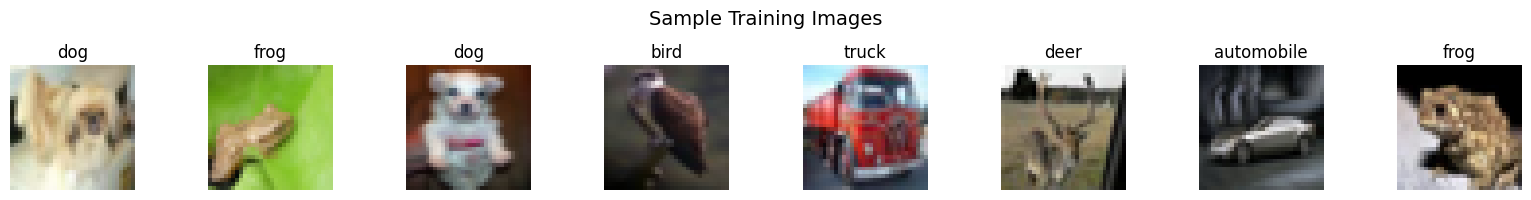

In [4]:
def imshow(img, title=None):
    """Display a normalized image."""
    img = img / 2 + 0.5  # un-normalize from [-1,1] to [0,1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Get one batch of training images
images, labels = next(iter(train_loader))

# Show first 8 images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(np.transpose((images[i] / 2 + 0.5).numpy(), (1, 2, 0)))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

## Step 5 — Define the CNN Model

Our CNN architecture:

```
Input (3×32×32)
  → Conv2d(3→32, kernel=3, pad=1) → ReLU → MaxPool2d(2)   → (32×16×16)
  → Conv2d(32→64, kernel=3, pad=1) → ReLU → MaxPool2d(2)  → (64×8×8)
  → Conv2d(64→128, kernel=3, pad=1) → ReLU → MaxPool2d(2) → (128×4×4)
  → Flatten → (2048)
  → Linear(2048→256) → ReLU → Dropout(0.5)
  → Linear(256→10)
```

**Key concepts:**
- **Conv2d**: Slides small filters over the image to detect features (edges, textures, shapes)
- **ReLU**: Non-linear activation — lets the network learn complex patterns
- **MaxPool2d**: Downsamples by taking the max in each 2×2 window — reduces spatial size and provides translation invariance
- **Flatten**: Converts the 3D feature maps to a 1D vector for the fully connected layers
- **Linear (FC)**: Standard fully connected layer for classification
- **Dropout**: Randomly zeros some neurons during training to prevent overfitting

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Conv block 1: 3 input channels → 32 feature maps
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 → 16x16
            
            # Conv block 2: 32 → 64 feature maps
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 → 8x8
            
            # Conv block 3: 64 → 128 feature maps
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 → 4x4
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                        # 128*4*4 = 2048
            nn.Linear(128 * 4 * 4, 256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),                     # Regularization
            nn.Linear(128, num_classes),          # Output: 10 classes
        )
    
    def forward(self, x):
        x = self.conv_layers(x)   # Feature extraction
        x = self.fc_layers(x)     # Classification
        return x

# Create model and move to device
model = CNN(num_classes=10).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 620,362
Trainable parameters: 620,362


## Step 6 — Define Loss Function & Optimizer

- **CrossEntropyLoss**: Standard loss for multi-class classification. Combines `LogSoftmax` + `NLLLoss`.
- **Adam optimizer**: Adaptive learning rate optimizer — works well out of the box for most tasks.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam with lr=0.001")

Loss function: CrossEntropyLoss()
Optimizer: Adam with lr=0.001


## Step 7 — Training Loop

In each epoch, we:
1. Iterate over all batches in the training set
2. Forward pass: compute predictions
3. Compute loss
4. Backward pass: compute gradients
5. Update weights with the optimizer

We train for **3 epochs** (enough for a demo — for better accuracy, train longer).

In [7]:
num_epochs = 3
train_losses = []

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()        # Compute gradients
        optimizer.step()       # Update weights
        
        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Print every 200 batches
        if (batch_idx + 1) % 200 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], "
                  f"Batch [{batch_idx+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete!")

  Epoch [1/3], Batch [200/782], Loss: 1.7424
  Epoch [1/3], Batch [400/782], Loss: 1.6814
  Epoch [1/3], Batch [600/782], Loss: 1.4402
Epoch [1/3] — Loss: 1.5019, Accuracy: 44.83%
  Epoch [2/3], Batch [200/782], Loss: 1.0678
  Epoch [2/3], Batch [400/782], Loss: 1.1698
  Epoch [2/3], Batch [600/782], Loss: 1.0348
Epoch [2/3] — Loss: 1.1012, Accuracy: 60.77%
  Epoch [3/3], Batch [200/782], Loss: 0.8545
  Epoch [3/3], Batch [400/782], Loss: 0.8835
  Epoch [3/3], Batch [600/782], Loss: 0.9317
Epoch [3/3] — Loss: 0.9234, Accuracy: 67.62%

Training complete!


## Step 8 — Plot Training Loss

Visualizing the loss curve helps us understand if the model is learning. A decreasing loss means the model is improving.

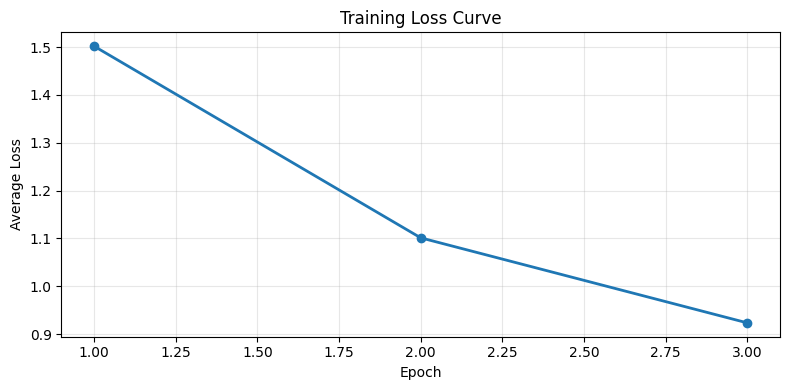

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — Evaluate on Test Set

We evaluate the model on the **test set** (data the model has never seen during training) to measure its generalization ability.

We use `torch.no_grad()` to disable gradient computation — this speeds up inference and reduces memory usage.

In [ ]:
model.eval()  # Set model to evaluation mode (disables dropout)
correct = 0
total = 0

# Per-class accuracy tracking
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():  # No gradient computation needed for evaluation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Per-class stats
        for i in range(labels.size(0)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

print(f"Overall Test Accuracy: {100 * correct / total:.2f}%")
print(f"\nPer-class Accuracy:")
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"  {classes[i]:>12s}: {acc:.1f}%")

Overall Test Accuracy: 71.55%

Per-class Accuracy:
      airplane: 81.9%
    automobile: 82.2%
          bird: 66.8%
           cat: 55.6%
          deer: 61.8%
           dog: 51.6%
          frog: 79.3%
         horse: 73.9%
          ship: 84.5%
         truck: 77.9%


## Step 10 — Visualize Predictions

Let's see how the model performs on individual test images. Green titles mean the prediction is correct, red means incorrect.

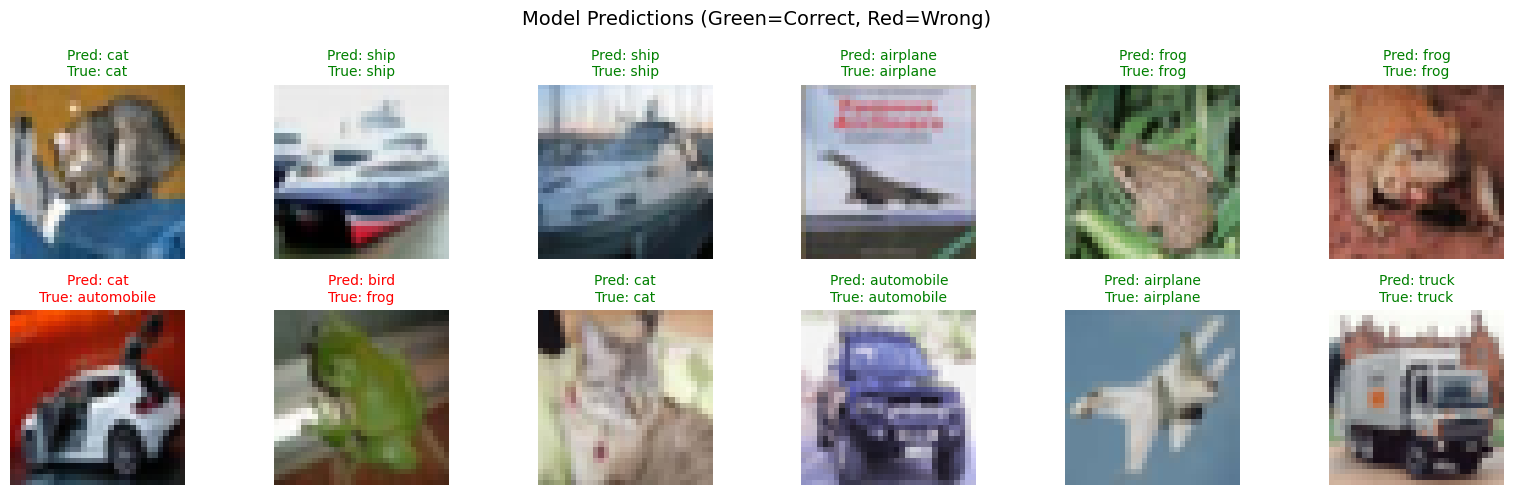

In [10]:
# Get a batch of test images
images, labels = next(iter(test_loader))
images_dev = images.to(device)

# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(images_dev)
    _, predicted = torch.max(outputs, 1)

# Show first 12 images with predictions
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # un-normalize
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    
    pred_label = classes[predicted[i]]
    true_label = classes[labels[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:
1. **Loaded** the CIFAR-10 dataset with normalization transforms
2. **Built** a CNN with 3 convolutional blocks + 2 fully connected layers
3. **Trained** the model for 3 epochs using CrossEntropyLoss and Adam optimizer
4. **Evaluated** on the test set and visualized per-class accuracy
5. **Visualized** individual predictions

**Key takeaways:**
- CNNs learn hierarchical features: early layers detect edges, later layers detect complex patterns
- Even a simple 3-layer CNN can achieve ~70%+ accuracy on CIFAR-10 in just 3 epochs
- For better accuracy: train longer, use data augmentation, add batch normalization, use deeper architectures (ResNet, etc.)

**Next steps to try:**
- Add `transforms.RandomHorizontalFlip()` and `transforms.RandomCrop(32, padding=4)` for data augmentation
- Add `nn.BatchNorm2d()` after each Conv2d layer
- Increase training epochs to 20-30
- Try a learning rate scheduler